## 1. Import class definition for custom ensemble model

We use a custom class definition of our model as it aggregates the prediction probabilities returned by each component model pipeline.

We can then load the model pickle file.

In [1]:
import pickle

class UltraEnsembleModel:
    """Combines multiple models via majority voting"""

    def __init__(self, models_dict, feature_selector=None):
        self.models = models_dict

    def predict(self, X):
        all_preds = {}
        for name, model in self.models.items():
             all_preds[name] = model.predict(X)
        # Majority voting
        n_samples = len(X)
        final_preds = []
        for i in range(n_samples):
            votes = [pred[i] for pred in all_preds.values()]
            final_preds.append(max(set(votes), key=votes.count))
        return np.array(final_preds)

    def predict_proba(self, X):
        all_probas = dict()
        for name, model in self.models.items():
            all_probas[name] = model.predict_proba(X)
        # Average probabilities
        return np.mean(list(all_probas.values()), axis=0), all_probas

with open('ultra_ensemble_model_optimised.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Extract components
model = bundle['model']
class_labels = bundle['class_labels']

## 2. Extract features of input data

Our expected input format begins with an audio file in a .wav format. We use the librosa library to load the .wav file and process the data into the features that can then be used in our model.

In [2]:
import librosa
import numpy as np


def extract_features_enhanced(path):
    """
    Extract 210 features:
    - Original 162 features
    - Delta MFCCs (20)
    - Delta-Delta MFCCs (20)
    - Prosodic features (8)
    """
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    data, index = librosa.effects.trim(data, top_db=20)
    result = np.array([])
    
    # === ORIGINAL FEATURES (162) ===
    # ZCR (1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))
    
    # Chroma STFT (12)
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    result = np.hstack((result, chroma_stft))
    
    # MFCC (20)
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    result = np.hstack((result, mfcc_mean))
    
    # RMS (1)
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))
    
    # Mel Spectrogram (128)
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, mel))
    
    # === NEW: DELTA FEATURES (40) ===
    # Delta MFCC (20) - first derivative
    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mfcc_mean = np.mean(delta_mfcc.T, axis=0)
    result = np.hstack((result, delta_mfcc_mean))
    
    # Delta-Delta MFCC (20) - second derivative
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    delta2_mfcc_mean = np.mean(delta2_mfcc.T, axis=0)
    result = np.hstack((result, delta2_mfcc_mean))
    
    # === NEW: PROSODIC FEATURES (8) ===
    # Pitch statistics (5)
    pitches, magnitudes = librosa.piptrack(y=data, sr=sr)
    pitch_values = pitches[pitches > 0]
    
    if len(pitch_values) > 0:
        pitch_mean = np.mean(pitch_values)
        pitch_std = np.std(pitch_values)
        pitch_max = np.max(pitch_values)
        pitch_min = np.min(pitch_values)
        pitch_range = pitch_max - pitch_min
    else:
        pitch_mean = pitch_std = pitch_max = pitch_min = pitch_range = 0
    
    # Energy dynamics (3)
    rms_full = librosa.feature.rms(y=data)[0]
    energy_std = np.std(rms_full)
    energy_slope = np.polyfit(range(len(rms_full)), rms_full, 1)[0] if len(rms_full) > 1 else 0
    energy_range = np.max(rms_full) - np.min(rms_full) if len(rms_full) > 0 else 0
    
    prosodic = np.array([pitch_mean, pitch_std, pitch_range, pitch_max, pitch_min,
                         energy_std, energy_slope, energy_range])
    result = np.hstack((result, prosodic))
    
    return result

## 3. Load audio data

Next, we need to obtain new audio data. For the purpose of testing, we obtain audio datasets from the following:
1. Crowd Sourced Emotional Multimodal Actors Dataset (CREMA-D) (https://www.kaggle.com/datasets/ejlok1/cremad)
2. Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS) (https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio)
3. Surrey Audio-Visual Expressed Emotion (SAVEE) (https://www.kaggle.com/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee)
4. Toronto emotional speech set (TESS) (https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess)

### CREMA-D

In [3]:
import os
import pandas as pd


Crema = "./AudioWAV/"
crema_directory_list = os.listdir(Crema)

file_emotion = []
file_path = []

for file in crema_directory_list:
    if not file.lower().endswith('.wav'):
        continue
    # storing file paths
    file_path.append(Crema + file)
    # storing file emotions
    part=file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotion'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)
Crema_df = Crema_df[Crema_df['Emotion'] != 'Unknown']
demographics_df = pd.read_csv("VideoDemographics.csv")
actor_genders = []
Crema_df["ActorID"] = Crema_df["Path"].str.extract(pat=r'/(\d{4})_.+\.wav').astype(int)
Crema_df = pd.merge(Crema_df, demographics_df, on="ActorID", how="left")
Crema_df.sample(5)

,Emotion,Path,ActorID,Age,Sex,Race,Ethnicity
4813,angry,./AudioWAV/1059_WSI_ANG_XX.wav,1059,21,Male,African American,Not Hispanic
7435,sad,./AudioWAV/1091_TSI_SAD_XX.wav,1091,29,Female,Asian,Not Hispanic
339,fear,./AudioWAV/1005_IEO_FEA_HI.wav,1005,29,Male,African American,Not Hispanic
6190,fear,./AudioWAV/1076_TAI_FEA_XX.wav,1076,25,Female,Caucasian,Not Hispanic
3960,happy,./AudioWAV/1049_IWL_HAP_XX.wav,1049,25,Female,Caucasian,Hispanic


In [4]:
X = np.array([])
y = np.array([])

for idx, row in Crema_df.iterrows():
    path = row['Path']
    label = row['Emotion']
    try:
        X = np.vstack((X, extract_features_enhanced(path)))
    except ValueError:
        X = np.hstack((X, extract_features_enhanced(path)))
    y = np.hstack((y, label))
    if idx % 500 == 0:
        print('.', end='')

.............

C:\Users\seowcy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


..

In [5]:
# Save features as csv
np.savetxt('features_crema.csv', X, delimiter=',', fmt='%f')
# Save labels as csv
np.savetxt('labels_crema.csv', y, delimiter=',', fmt='%s')

### RAVDESS

In [6]:
import os
import pandas as pd

Ravdess = "./RAVDESS/"
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    # as their are 20 different actors in our previous directory we need to extract files for each actor.
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # third part in each file represents the emotion associated to that file.
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotion'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df['Emotion'] = Ravdess_df['Emotion'].replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'})
Ravdess_df = Ravdess_df[~Ravdess_df['Emotion'].isin(['calm', 'surprise']) ]
Ravdess_df.sample(5)

,Emotion,Path
389,angry,./RAVDESS/Actor_07/03-01-05-01-01-02-07.wav
721,neutral,./RAVDESS/Actor_13/03-01-01-01-01-02-13.wav
1245,disgust,./RAVDESS/Actor_21/03-01-07-01-01-02-21.wav
824,disgust,./RAVDESS/Actor_14/03-01-07-01-01-01-14.wav
783,neutral,./RAVDESS/Actor_14/03-01-01-01-02-02-14.wav


In [7]:
X = np.array([])
y = np.array([])

for idx, row in Ravdess_df.iterrows():
    path = row['Path']
    label = row['Emotion']
    try:
        X = np.vstack((X, extract_features_enhanced(path)))
    except ValueError:
        X = np.hstack((X, extract_features_enhanced(path)))
    y = np.hstack((y, label))
    if idx % 500 == 0:
        print('.', end='')

...

In [8]:
# Save features as csv
np.savetxt('features_ravdess.csv', X, delimiter=',', fmt='%f')
# Save labels as csv
np.savetxt('labels_ravdess.csv', y, delimiter=',', fmt='%s')

### SAVEE

In [9]:
Savee = "./SAVEE/"
savee_directory_list = os.listdir(Savee)

file_emotion = []
file_path = []

for file in savee_directory_list:
    file_path.append(Savee + file)
    part = file.split('_')[1]
    ele = part[:-6]
    if ele=='a':
        file_emotion.append('angry')
    elif ele=='d':
        file_emotion.append('disgust')
    elif ele=='f':
        file_emotion.append('fear')
    elif ele=='h':
        file_emotion.append('happy')
    elif ele=='n':
        file_emotion.append('neutral')
    elif ele=='sa':
        file_emotion.append('sad')
    else:
        file_emotion.append('surprise')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotion'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Savee_df = pd.concat([emotion_df, path_df], axis=1)
Savee_df = Savee_df[~Savee_df['Emotion'].isin(['surprise']) ]
Savee_df.sample(5)

,Emotion,Path
285,happy,./SAVEE/JK_h01.wav
454,sad,./SAVEE/KL_sa05.wav
334,sad,./SAVEE/JK_sa05.wav
451,sad,./SAVEE/KL_sa02.wav
71,neutral,./SAVEE/DC_n12.wav


In [10]:
X = np.array([])
y = np.array([])

for idx, row in Savee_df.iterrows():
    path = row['Path']
    label = row['Emotion']
    try:
        X = np.vstack((X, extract_features_enhanced(path)))
    except ValueError:
        X = np.hstack((X, extract_features_enhanced(path)))
    y = np.hstack((y, label))
    if idx % 500 == 0:
        print('.', end='')

.

In [11]:
# Save features as csv
np.savetxt('features_savee.csv', X, delimiter=',', fmt='%f')
# Save labels as csv
np.savetxt('labels_savee.csv', y, delimiter=',', fmt='%s')

### TESS

In [12]:
Tess = "./TESS/"
tess_directory_list = os.listdir(Tess)

file_emotion = []
file_path = []

for dir in tess_directory_list:
    directories = os.listdir(Tess + dir)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(Tess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotion'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df = Tess_df[~Tess_df['Emotion'].isin(['surprise']) ]
Tess_df.sample(5)

,Emotion,Path
1608,disgust,./TESS/YAF_disgust/YAF_bone_disgust.wav
1310,sad,./TESS/OAF_Sad/OAF_near_sad.wav
239,disgust,./TESS/OAF_disgust/OAF_far_disgust.wav
44,angry,./TESS/OAF_angry/OAF_gap_angry.wav
1343,sad,./TESS/OAF_Sad/OAF_rush_sad.wav


In [13]:
X = np.array([])
y = np.array([])

for idx, row in Tess_df.iterrows():
    path = row['Path']
    label = row['Emotion']
    try:
        X = np.vstack((X, extract_features_enhanced(path)))
    except ValueError:
        X = np.hstack((X, extract_features_enhanced(path)))
    y = np.hstack((y, label))
    if idx % 500 == 0:
        print('.', end='')

....

In [14]:
# Save features as csv
np.savetxt('features_tess.csv', X, delimiter=',', fmt='%f')
# Save labels as csv
np.savetxt('labels_tess.csv', y, delimiter=',', fmt='%s')

## 4. Use model to predict emotion from audio from a dataset


Ultra Ensemble accuracy: 0.4119 (41.19%)
Class labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']

Confusion Matrix:
         angry  disgust  fear  happy  neutral  sad
angry       96       43    16     24        8    5
disgust      5       90    28     16        5   48
fear        17       32    79     32        6   26
happy       16       48    29     67       13   19
neutral      0       21     3      1        8   63
sad          1       53    18     23        2   95


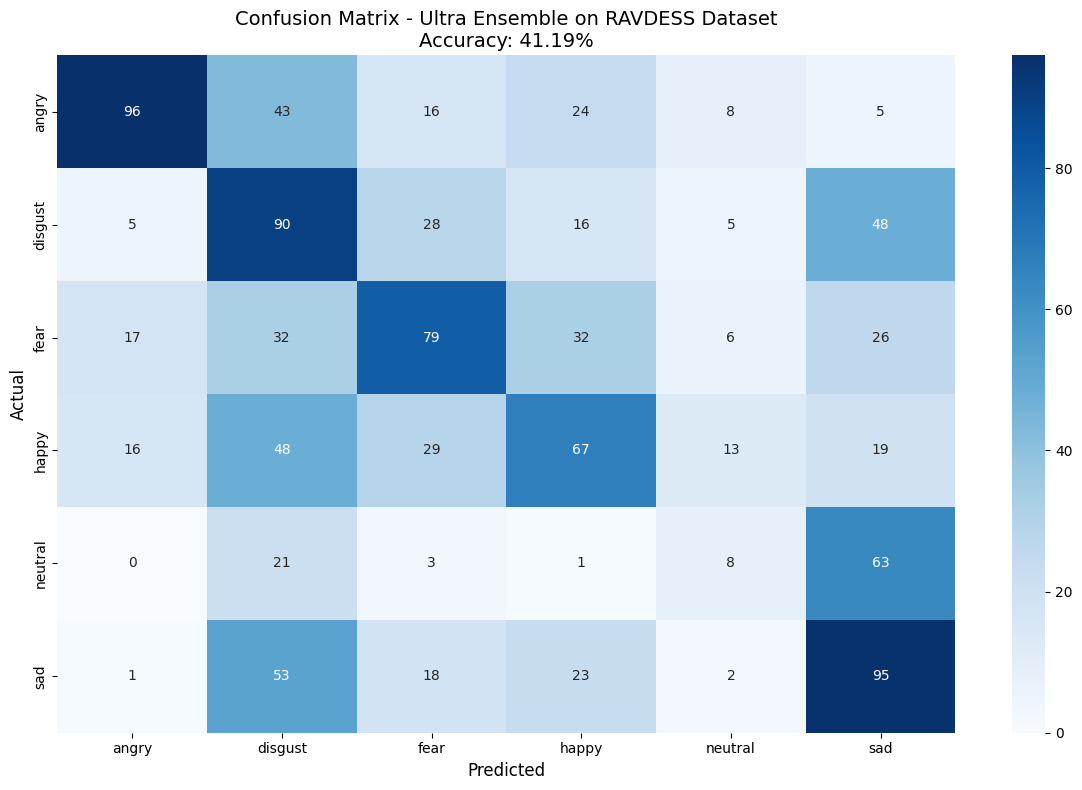

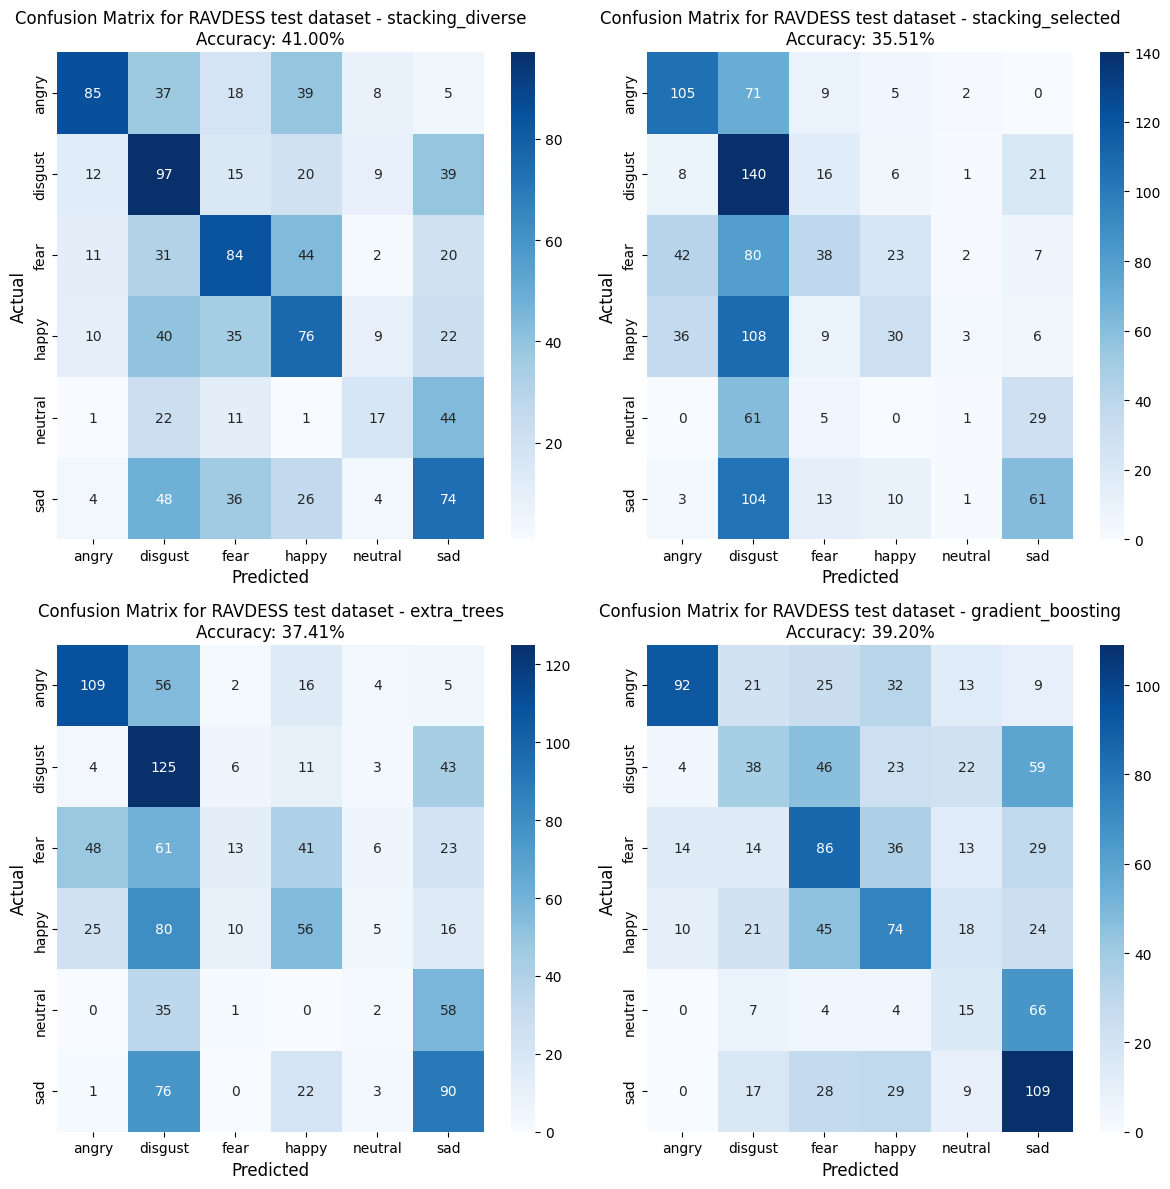

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

######################################
# Select option:
# 0 - CREMA-D
# 1 - RAVDESS
# 2 - SAVEE
# 3 - TESS
######################################

option = 1
test_set_list = ["crema", "ravdess", "savee", "tess"]
test_set = test_set_list[option]

X = pd.read_csv(f'features_{test_set}.csv', header=None).values
y = np.ravel(pd.read_csv(f'labels_{test_set}.csv', header=None).values)
y_pred_proba, all_proba = model.predict_proba(X)
y_pred_best = [class_labels[i] for i in np.argmax(y_pred_proba, axis=1)]
best_accuracy_final = accuracy_score(y, y_pred_best)
# Generate confusion matrix
cm_array = confusion_matrix(y, y_pred_best)

print(f"\nUltra Ensemble accuracy: {best_accuracy_final:.4f} ({best_accuracy_final*100:.2f}%)")
print(f"Class labels: {class_labels}")

# Display confusion matrix
print("\nConfusion Matrix:")
print(pd.DataFrame(cm_array, index=class_labels, columns=class_labels))

# Visualize confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix - Ultra Ensemble on {test_set.upper()} Dataset\nAccuracy: {best_accuracy_final*100:.2f}%', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

plot_idx = 1
plt.figure(figsize=(12, 12))
for key in model.models:
    y_pred = [class_labels[i] for i in np.argmax(all_proba[key], axis=1)]
    accuracy = accuracy_score(y, y_pred)
    cm_array = confusion_matrix(y, y_pred)
    
    # Visualize confusion matrix
    plt.subplot(2, 2, plot_idx)
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix for {test_set.upper()} test dataset - {key}\nAccuracy: {accuracy*100:.2f}%')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plot_idx += 1

plt.tight_layout()
plt.show()

## 5. Inspect audio file sample waveforms and play audio

In [16]:
import matplotlib.pyplot as plt
from IPython.display import Audio

def create_waveplot(data, sr, e):
    plt.figure(figsize=(12, 3))
    plt.title(f'Waveplot - {e}', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def create_spectrogram(data, sr):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram', size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')

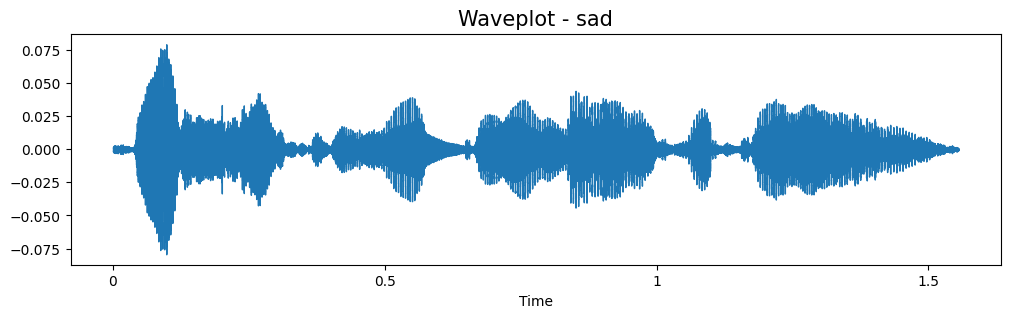

In [19]:
######################################
# Select option:
# 0 - CREMA-D
# 1 - RAVDESS
# 2 - SAVEE
# 3 - TESS
######################################

option = 1
test_set_df_list = [Crema_df, Ravdess_df, Savee_df, Tess_df]
test_set_df = test_set_df_list[option]

idx = np.random.choice(len(test_set_df))
path = test_set_df['Path'].iloc[idx]
e = test_set_df['Emotion'].iloc[idx]
data, sampling_rate = librosa.load(path, duration=2.5, offset=0.6)
data, index = librosa.effects.trim(data, top_db=20)
create_waveplot(data, sampling_rate, e)
Audio(data,rate=sampling_rate)

## 6. Randomly sample and inspect wrong predictions or low confidence results

In [31]:
######################################
# Select option:
# 0 - CREMA-D
# 1 - RAVDESS
# 2 - SAVEE
# 3 - TESS
######################################

option = 1
test_set_df_list = [Crema_df, Ravdess_df, Savee_df, Tess_df]
test_set_df = test_set_df_list[option]

sample_label = "DUMMY"
y_pred = ["DUMMY"]
max_proba = 1.0
threshold = 0.5
while sample_label == y_pred[0] and max_proba > threshold:
    sample_idx = np.random.choice(len(test_set_df))
    sample_path = test_set_df['Path'].values[sample_idx]
    sample_label = test_set_df['Emotion'].values[sample_idx]
    X = extract_features_enhanced(sample_path)
    y_pred_proba, all_probas = model.predict_proba([X])
    max_proba = np.max(y_pred_proba, axis=1)
    y_pred = [class_labels[i] for i in np.argmax(y_pred_proba, axis=1)]
    
print(f"Row: {sample_path} -> Prediction: {y_pred[0]} (Actual: {sample_label})\n")
print(f"total:\n\t{[f"{class_labels[i]}: {y_pred_proba[0][i]:.4f}" for i in range(len(class_labels))]}")
for key in model.models:
    print(f"{key}:\n\t{[f"{class_labels[i]}: {all_probas[key][0][i]:.4f}" for i in range(len(class_labels))]}")

Row: ./RAVDESS/Actor_24/03-01-03-02-02-02-24.wav -> Prediction: fear (Actual: happy)

total:
	['angry: 0.1287', 'disgust: 0.1020', 'fear: 0.5575', 'happy: 0.1577', 'neutral: 0.0243', 'sad: 0.0299']
stacking_diverse:
	['angry: 0.0062', 'disgust: 0.0642', 'fear: 0.7704', 'happy: 0.1238', 'neutral: 0.0013', 'sad: 0.0341']
stacking_selected:
	['angry: 0.2953', 'disgust: 0.2088', 'fear: 0.2313', 'happy: 0.1930', 'neutral: 0.0441', 'sad: 0.0275']
extra_trees:
	['angry: 0.2133', 'disgust: 0.1348', 'fear: 0.2282', 'happy: 0.3139', 'neutral: 0.0519', 'sad: 0.0578']
gradient_boosting:
	['angry: 0.0000', 'disgust: 0.0000', 'fear: 1.0000', 'happy: 0.0000', 'neutral: 0.0000', 'sad: 0.0000']
